In [2]:
from ultralytics import YOLO
import supervision as sv
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Load the Model

In [ ]:
model = YOLO('yolov8n.pt')
model.fuse() #for faster inference
model.to('cpu')

YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): ModuleList(
          (0-2): 3 x Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): Conv(
              (conv): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplac

In [4]:
# dict mapping class_id to class_name
CLASS_NAMES_DICT = model.model.names

# CLASS_NAMES_DICT

In [5]:
# class IDs of interest - car, motorcycles, bus, truck
classes =  [2, 3, 5, 7]

## Plot Frame from Video

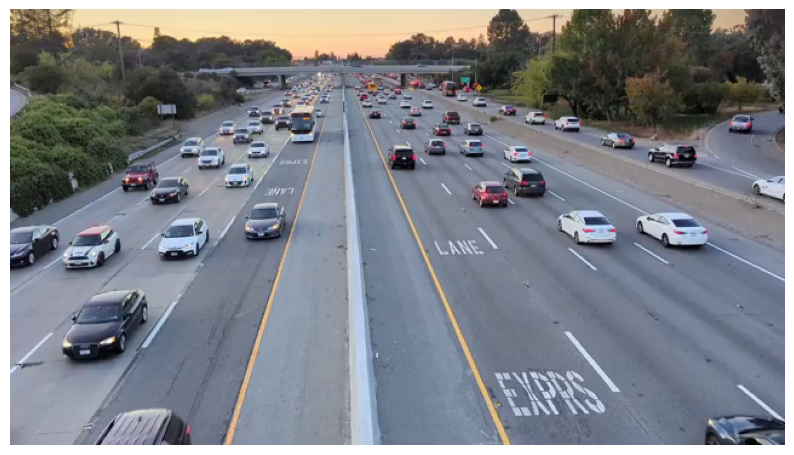

In [ ]:
# Download video from README and place in project folder
generator = sv.get_video_frames_generator('Highway-Footage1.mp4')

# get the first frame

iterator = iter(generator)
frame = next(iterator)
sv.plot_image(frame, (10,10))

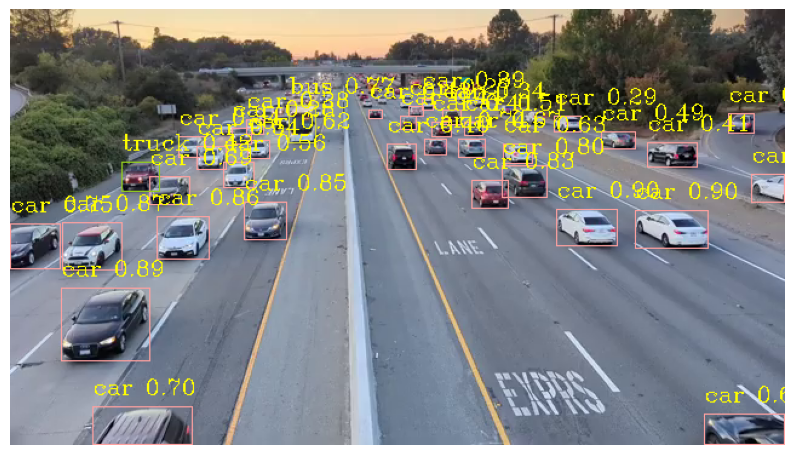

In [7]:
# detect vehicles from the frame
results = model(frame, verbose=False)[0]

#convert to detections
detections = sv.Detections.from_ultralytics(results)
#only consider classes which we require
detections = detections[np.isin(detections.class_id,classes)]

#create instance of box annotator
box_annotator = sv.BoxAnnotator(thickness=1)
#annotate in the frame
annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)

# format labels
labels = []
for confidence, class_id in zip(detections.confidence, detections.class_id):
    label = f'{CLASS_NAMES_DICT[class_id]} {confidence:0.2f}'
    labels.append(label)

#overlay labels in the bounding box
for box, label in zip(detections.xyxy, labels):
    x1, y1, x2, y2 = box.astype(int)

    # add the Label above the box
    cv2.putText(
        annotated_frame, label, (x1, y1-10), fontFace=cv2.FONT_HERSHEY_COMPLEX, fontScale=0.6,
        color=(0, 255, 255), thickness=1
    )
    
#plot the image
sv.plot_image(annotated_frame, (10, 10))

## Track and Count Vehicle

In [8]:
sv.VideoInfo.from_video_path('Highway-Footage2.mp4')

VideoInfo(width=640, height=360, fps=29, total_frames=4509)

In [9]:
# line config
LINE_START = sv.Point(0, 500)
LINE_END = sv.Point(1280, 500)

#create bytetracker instance
byte_tracker = sv.ByteTrack(frame_rate=25)

# create line zone counter instance
line_counter = sv.LineZone(start=LINE_START, end=LINE_END)

# create line zone annotator
line_zone_annotator = sv.LineZoneAnnotator(thickness=2, text_thickness=2, text_scale=1)

# create box annotator
box_annotator = sv.BoxAnnotator(thickness=2)

# create trace annotator
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=60)

In [10]:
#define the function for processing the frames
def process_frame(frame):
    #get results from  the model
    results = model(frame, verbose=False)[0]
    #convert to detections
    detections = sv.Detections.from_ultralytics(results)
    #only consider classes which we require
    detections = detections[np.isin(detections.class_id,classes)]
    #tracking detections
    detections= byte_tracker.update_with_detections(detections)

    #create labels
    labels = []    
    for confidence, class_id, tracker_id in zip(detections.confidence, detections.class_id,  detections.tracker_id):
        label = f'{tracker_id} {CLASS_NAMES_DICT[class_id]} {confidence:0.2f}'
        labels.append(label)

    # update trace annotator
    annotated_frame = trace_annotator.annotate(scene=frame.copy(), detections=detections)

    #update box annotator
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)

    #overlay labels in the bounding box
    for box, label in zip(detections.xyxy, labels):
        x1, y1, x2, y2 = box.astype(int)
    
        # add the Label above the box
        cv2.putText(
            annotated_frame, label, (x1, y1-10), fontFace=cv2.FONT_HERSHEY_COMPLEX, fontScale=0.4,
            color=(0, 255, 255), thickness=1
        )

    line_counter.trigger(detections)
    #update Line zone annotator
    annotated_frame = line_zone_annotator.annotate(annotated_frame, line_counter = line_counter)

    return annotated_frame

In [11]:
#run the program
video_path = 'Highway-Footage2.mp4'
#get input from webcam
#video_cap = cv2.Video_Capture(0) # capture from webcam
#get input from video
video_cap = cv2.VideoCapture(video_path)

while True:
    success, frame = video_cap.read()

    if not success:
        break

    #resize the frame
    frame = cv2.resize(frame, (1280, 720))
    #convert to RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    #process the frame
    processed_frame = process_frame(frame)
    #display the frame
    cv2.imshow("Highway Vehicle Tracking & Counting", processed_frame)

    #exit if any key presses
    if cv2.waitKey(1) & 0xFF != 255:
        break

video_cap.release()
cv2.destroyAllWindows()